
# CNN Image Classification with PyTorch — Rock, Paper, Scissors

**Student:** MD Abir Hossain  
**Roll:** 220144  
**Department/University:** CSE, Jashore University of Science and Technology (JUST)

This notebook follows the assignment workflow:
1. Automatically clone the GitHub repository.
2. Automatically download the standard Rock-Paper-Scissors dataset.
3. Preprocess images using `Resize → ToTensor → Normalize`.
4. Build and train a CNN with PyTorch.
5. Evaluate on a held-out standard test set.
6. Save/load the trained model state dictionary.
7. Automatically load the **10 custom smartphone images** from `CNN/dataset/`.
8. Predict class and confidence for every custom image.
9. Display training-history plots, confusion matrix, custom prediction gallery, and 3 random errors.

**Custom GitHub dataset:** `CNN/dataset/`  
Files used: 4 paper, 3 rock, and 3 scissors images (10 images total).


## 1. Setup and GitHub Repository

In [1]:

import os
import sys
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

REPO_URL = "https://github.com/abir945/AI_ML_LAB.git"
REPO_DIR = "/content/AI_ML_LAB"
CNN_DIR = os.path.join(REPO_DIR, "CNN")
CUSTOM_DIR = os.path.join(CNN_DIR, "dataset")
MODEL_DIR = os.path.join(CNN_DIR, "model")
MODEL_PATH = os.path.join(MODEL_DIR, "220144.pth")

print("Repository:", REPO_URL)
print("Custom image folder:", CUSTOM_DIR)
print("Model path:", MODEL_PATH)


Repository: https://github.com/abir945/AI_ML_LAB.git
Custom image folder: /content/AI_ML_LAB/CNN/dataset
Model path: /content/AI_ML_LAB/CNN/model/220144.pth


In [2]:

# Clone the student's repository automatically.
if os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)

import subprocess
subprocess.run(["git", "clone", "-q", REPO_URL, REPO_DIR], check=True)

print("Repository cloned successfully.")
print("CNN contents:", os.listdir(CNN_DIR))
print("Custom dataset contents:", sorted(os.listdir(CUSTOM_DIR)))


Repository cloned successfully.
CNN contents: ['dataset']
Custom dataset contents: ['paper_01.jpg', 'paper_02.jpg', 'paper_03.jpg', 'paper_04.jpg', 'rock_01.jpg', 'rock_02.jpg', 'rock_03.jpg', 'scissors_01.jpg', 'scissors_02.jpg', 'scissors_03.jpg']


In [3]:

# Verify the 10 custom images required by the assignment.
valid_ext = {".jpg", ".jpeg", ".png"}
custom_paths = sorted(
    os.path.join(CUSTOM_DIR, f)
    for f in os.listdir(CUSTOM_DIR)
    if os.path.splitext(f.lower())[1] in valid_ext
)

print("Total custom images:", len(custom_paths))
for p in custom_paths:
    print("-", os.path.basename(p))

assert len(custom_paths) == 10, (
    f"Expected 10 custom images, but found {len(custom_paths)}."
)

# Expected labels are encoded in filenames such as paper_01.jpg.
custom_labels_from_filename = [os.path.basename(p).split("_")[0].lower() for p in custom_paths]
print("\nCustom filename labels:", custom_labels_from_filename)


Total custom images: 10
- paper_01.jpg
- paper_02.jpg
- paper_03.jpg
- paper_04.jpg
- rock_01.jpg
- rock_02.jpg
- rock_03.jpg
- scissors_01.jpg
- scissors_02.jpg
- scissors_03.jpg

Custom filename labels: ['paper', 'paper', 'paper', 'paper', 'rock', 'rock', 'rock', 'scissors', 'scissors', 'scissors']



## 2. Automatic Download of the Standard RPS Dataset

The standard Rock-Paper-Scissors image dataset is downloaded automatically from TensorFlow's public dataset URL. The archive is downloaded with a torchvision utility and then loaded with `torchvision.datasets.ImageFolder`.

This keeps the runtime automatic and avoids any manual file upload.


In [4]:

import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
from torchvision.datasets.utils import download_and_extract_archive
from torch.utils.data import DataLoader, random_split

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())


PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA available: True


In [5]:

RPS_URL = "https://storage.googleapis.com/download.tensorflow.org/data/rps.zip"
STANDARD_DIR = "/content/rps_data"
RPS_ROOT = os.path.join(STANDARD_DIR, "rps")

os.makedirs(STANDARD_DIR, exist_ok=True)

if not os.path.isdir(RPS_ROOT):
    print("Downloading standard RPS dataset...")
    download_and_extract_archive(
        url=RPS_URL,
        download_root=STANDARD_DIR,
        filename="rps.zip",
        remove_finished=False
    )
    print("Standard RPS dataset downloaded and extracted.")
else:
    print("Standard RPS dataset already exists.")

for class_name in ["paper", "rock", "scissors"]:
    class_dir = os.path.join(RPS_ROOT, class_name)
    print(f"{class_name:10s}: {len(os.listdir(class_dir))} images")


100%|██████████| 201M/201M [00:00<00:00, 214MB/s]


Standard RPS dataset downloaded and extracted.
paper     : 840 images
rock      : 840 images
scissors  : 840 images


## 3. Data Preprocessing and Train/Validation/Test Split

In [6]:

IMAGE_SIZE = (128, 128)
BATCH_SIZE = 64

# Exact preprocessing required for standard training and custom images.
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

standard_dataset = datasets.ImageFolder(
    root=RPS_ROOT,
    transform=transform
)

CLASS_NAMES = standard_dataset.classes
print("Classes:", CLASS_NAMES)


Classes: ['paper', 'rock', 'scissors']


In [7]:

# Reproducible 70/15/15 split.
total_size = len(standard_dataset)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset, test_dataset = random_split(
    standard_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)

print("Total images     :", len(standard_dataset))
print("Training images  :", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images      :", len(test_dataset))


Total images     : 2520
Training images  : 1764
Validation images: 378
Test images      : 378


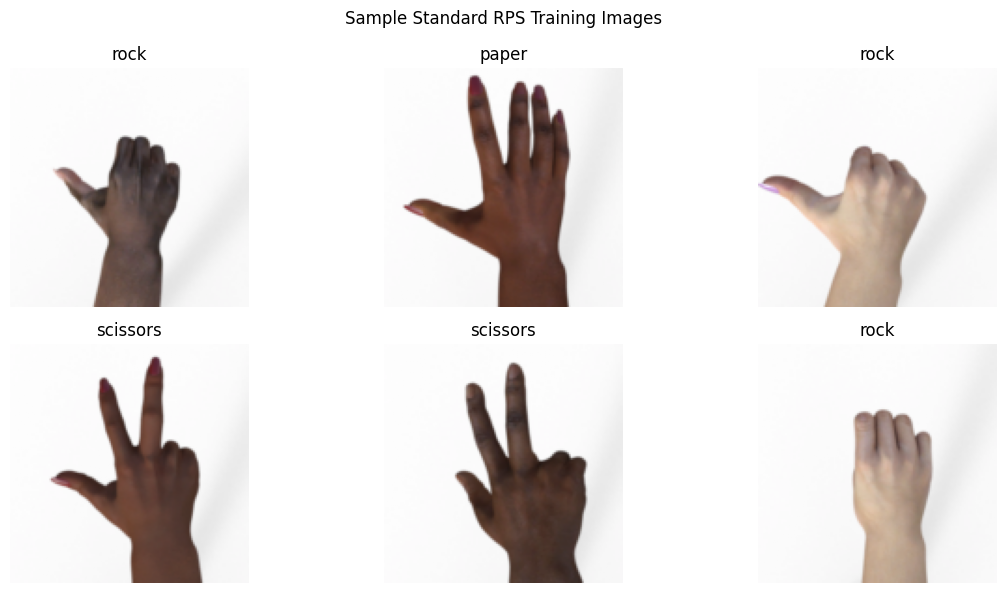

In [8]:

# Show sample training images.
images, labels = next(iter(train_loader))

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

plt.figure(figsize=(12, 6))
for i in range(min(6, len(images))):
    img = torch.clamp(images[i].cpu() * std + mean, 0, 1)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(CLASS_NAMES[labels[i].item()])
    plt.axis("off")

plt.suptitle("Sample Standard RPS Training Images")
plt.tight_layout()
plt.show()


## 4. CNN Model Architecture

In [9]:

class CNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        # 128x128 -> 64 -> 32 -> 16 -> 8
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN(num_classes=len(CLASS_NAMES)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)
print("\nDevice:", device)
print("Loss:", criterion)
print("Optimizer:", optimizer.__class__.__name__)


CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=3, bias=True)
  )
)

Devic

## 5. Training and Validation

In [10]:

def evaluate_loader(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, 100.0 * correct / total


EPOCHS = 15
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = 100.0 * correct / total

    val_loss, val_acc = evaluate_loader(
        model, val_loader, criterion, device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%"
    )


Epoch 01/15 | Train Loss: 0.6856 | Train Acc: 67.35% | Val Loss: 0.1154 | Val Acc: 96.03%
Epoch 02/15 | Train Loss: 0.0284 | Train Acc: 99.15% | Val Loss: 0.0215 | Val Acc: 98.68%
Epoch 03/15 | Train Loss: 0.0035 | Train Acc: 99.94% | Val Loss: 0.0003 | Val Acc: 100.00%
Epoch 04/15 | Train Loss: 0.0004 | Train Acc: 100.00% | Val Loss: 0.0001 | Val Acc: 100.00%
Epoch 05/15 | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0000 | Val Acc: 100.00%
Epoch 06/15 | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0000 | Val Acc: 100.00%
Epoch 07/15 | Train Loss: 0.0000 | Train Acc: 100.00% | Val Loss: 0.0000 | Val Acc: 100.00%
Epoch 08/15 | Train Loss: 0.0001 | Train Acc: 100.00% | Val Loss: 0.0000 | Val Acc: 100.00%
Epoch 09/15 | Train Loss: 0.0000 | Train Acc: 100.00% | Val Loss: 0.0000 | Val Acc: 100.00%
Epoch 10/15 | Train Loss: 0.0000 | Train Acc: 100.00% | Val Loss: 0.0000 | Val Acc: 100.00%
Epoch 11/15 | Train Loss: 0.0000 | Train Acc: 100.00% | Val Loss: 0.0000 | Val Acc: 1

## 6. Training History Plots

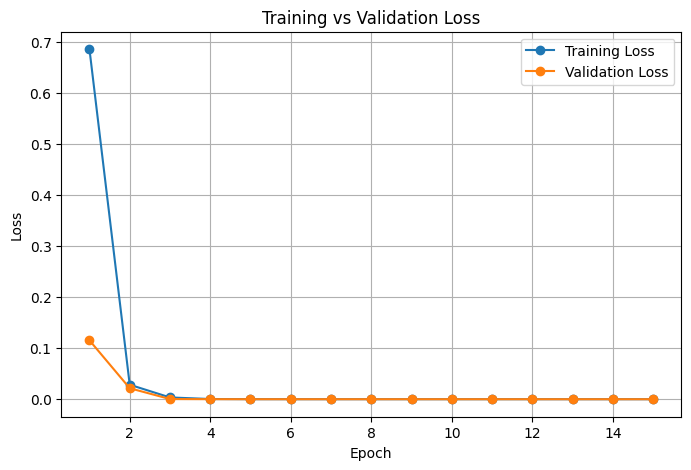

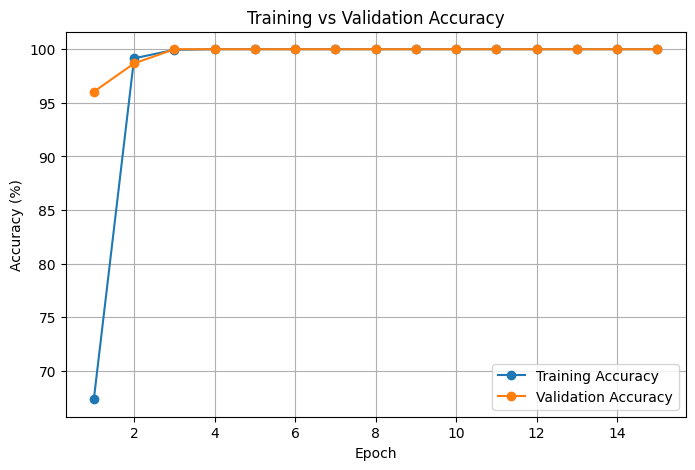

In [11]:

epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker="o", label="Training Loss")
plt.plot(epochs, val_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, marker="o", label="Training Accuracy")
plt.plot(epochs, val_accuracies, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


## 7. Save the Trained Model

In [12]:

os.makedirs(MODEL_DIR, exist_ok=True)

torch.save(model.state_dict(), MODEL_PATH)

print("Model saved successfully.")
print("Path:", MODEL_PATH)
print("Size: %.2f MB" % (os.path.getsize(MODEL_PATH) / (1024 ** 2)))


Model saved successfully.
Path: /content/AI_ML_LAB/CNN/model/220144.pth
Size: 17.49 MB


In [22]:
from google.colab import files

if os.path.exists(MODEL_PATH):
    print(f"Downloading model from: {MODEL_PATH}")
    files.download(MODEL_PATH)
else:
    print("Model file not found. Please ensure the training cell was executed successfully.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Standard Test-Set Evaluation and Confusion Matrix

In [13]:

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)

model.eval()
all_test_labels = []
all_test_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        predictions = outputs.argmax(dim=1).cpu().numpy()

        all_test_predictions.extend(predictions)
        all_test_labels.extend(labels.numpy())

test_accuracy = accuracy_score(all_test_labels, all_test_predictions)
test_precision = precision_score(
    all_test_labels, all_test_predictions,
    average="weighted", zero_division=0
)
test_recall = recall_score(
    all_test_labels, all_test_predictions,
    average="weighted", zero_division=0
)
test_f1 = f1_score(
    all_test_labels, all_test_predictions,
    average="weighted", zero_division=0
)

print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Precision     : {test_precision:.4f}")
print(f"Recall        : {test_recall:.4f}")
print(f"F1 Score      : {test_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        all_test_labels,
        all_test_predictions,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


Test Accuracy : 100.00%
Precision     : 1.0000
Recall        : 1.0000
F1 Score      : 1.0000

Classification Report:
              precision    recall  f1-score   support

       paper     1.0000    1.0000    1.0000       115
        rock     1.0000    1.0000    1.0000       135
    scissors     1.0000    1.0000    1.0000       128

    accuracy                         1.0000       378
   macro avg     1.0000    1.0000    1.0000       378
weighted avg     1.0000    1.0000    1.0000       378



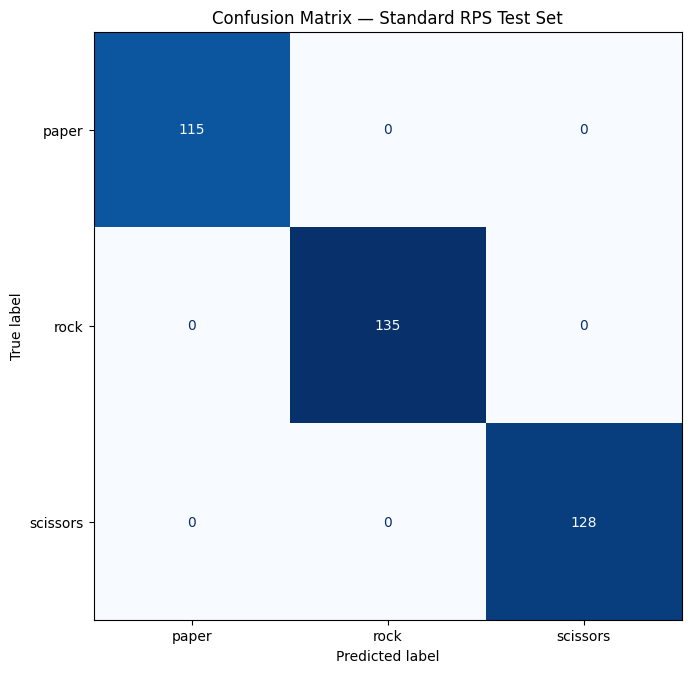

In [14]:

cm = confusion_matrix(all_test_labels, all_test_predictions)

fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("Confusion Matrix — Standard RPS Test Set")
plt.tight_layout()
plt.show()


## 9. Load the Saved Model (Reproducible Submission Flow)

In [20]:

# Re-create a fresh model and load the saved state dictionary.
loaded_model = CNN(num_classes=len(CLASS_NAMES)).to(device)

if os.path.exists(MODEL_PATH):
    loaded_model.load_state_dict(
        torch.load(MODEL_PATH, map_location=device)
    )
    loaded_model.eval()
    print("Saved model loaded successfully from:")
    print(MODEL_PATH)
else:
    loaded_model = model
    loaded_model.eval()
    print("Saved model was not found; using the trained model from this runtime.")

model = loaded_model


Saved model loaded successfully from:
/content/AI_ML_LAB/CNN/model/220144.pth


## 10. Real-World Prediction on the 10 Custom Smartphone Images

In [21]:

def predict_image(image_path, model, transform, class_names, device):
    image = Image.open(image_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probabilities = torch.softmax(logits, dim=1)
        confidence, predicted = probabilities.max(dim=1)

    return class_names[predicted.item()], confidence.item() * 100.0, image


custom_results = []

for image_path in custom_paths:
    predicted_class, confidence, image = predict_image(
        image_path, model, transform, CLASS_NAMES, device
    )

    actual_class = os.path.basename(image_path).split("_")[0].lower()
    custom_results.append({
        "path": image_path,
        "actual": actual_class,
        "predicted": predicted_class,
        "confidence": confidence,
        "image": image
    })

print("Custom-image predictions:")
for r in custom_results:
    print(
        f"{os.path.basename(r['path']):18s} | "
        f"Actual: {r['actual']:8s} | "
        f"Predicted: {r['predicted']:8s} | "
        f"Confidence: {r['confidence']:.2f}%"
    )


Custom-image predictions:
paper_01.jpg       | Actual: paper    | Predicted: rock     | Confidence: 99.73%
paper_02.jpg       | Actual: paper    | Predicted: rock     | Confidence: 100.00%
paper_03.jpg       | Actual: paper    | Predicted: rock     | Confidence: 100.00%
paper_04.jpg       | Actual: paper    | Predicted: rock     | Confidence: 99.71%
rock_01.jpg        | Actual: rock     | Predicted: rock     | Confidence: 100.00%
rock_02.jpg        | Actual: rock     | Predicted: rock     | Confidence: 100.00%
rock_03.jpg        | Actual: rock     | Predicted: rock     | Confidence: 100.00%
scissors_01.jpg    | Actual: scissors | Predicted: rock     | Confidence: 97.94%
scissors_02.jpg    | Actual: scissors | Predicted: scissors | Confidence: 74.19%
scissors_03.jpg    | Actual: scissors | Predicted: rock     | Confidence: 99.92%


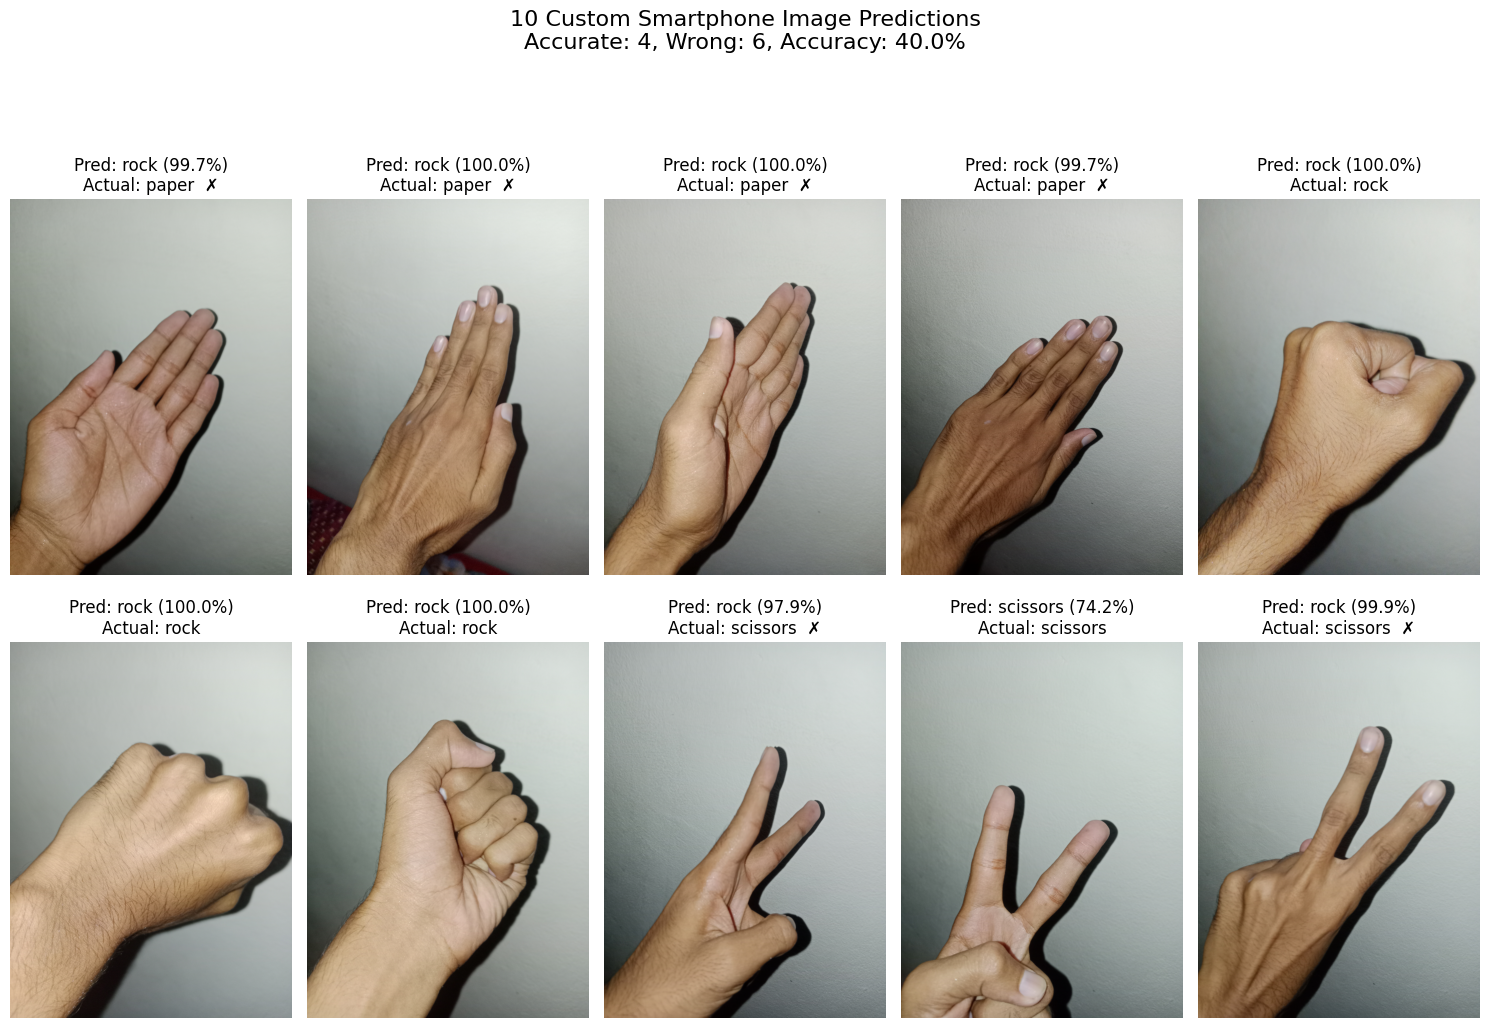

In [19]:

# Assignment-required custom prediction gallery.
plt.figure(figsize=(15, 12))

correct_count = 0
total_count = len(custom_results)

for i, result in enumerate(custom_results):
    plt.subplot(2, 5, i + 1)
    plt.imshow(result["image"])

    is_correct = result["actual"] == result["predicted"]
    if is_correct:
        correct_count += 1

    title = (
        f"Pred: {result['predicted']} ({result['confidence']:.1f}%)\n"
        f"Actual: {result['actual']}"
    )
    if not is_correct:
        title += "  ✗"

    plt.title(title)
    plt.axis("off")

wrong_count = total_count - correct_count
accuracy_pct = (correct_count / total_count) * 100

main_title = (
    f"10 Custom Smartphone Image Predictions\n"
    f"Accurate: {correct_count}, Wrong: {wrong_count}, Accuracy: {accuracy_pct:.1f}%"
)

plt.suptitle(main_title, fontsize=16, y=0.95)
plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.show()


## 11. Visual Error Analysis — 3 Random Misclassified Standard-Test Images

In [24]:
# ============================================================
# 11. Visual Error Analysis
# Show up to 3 random misclassified test images
# ============================================================

import random
import matplotlib.pyplot as plt

model.eval()

misclassified = []

with torch.no_grad():
    for idx in range(len(test_dataset)):

        # Get image and true label
        image_tensor, true_label = test_dataset[idx]

        # Add batch dimension
        input_tensor = image_tensor.unsqueeze(0).to(device)

        # Model prediction
        output = model(input_tensor)

        # Predicted class
        predicted_label = torch.argmax(output, dim=1).item()

        # Keep only wrong predictions
        if predicted_label != true_label:
            misclassified.append({
                "index": idx,
                "image": image_tensor.cpu(),
                "true": true_label,
                "predicted": predicted_label
            })

print("Total test images:", len(test_dataset))
print("Total misclassified images:", len(misclassified))


# ------------------------------------------------------------
# Select 3 random misclassified images
# ------------------------------------------------------------

if len(misclassified) == 0:

    print("\nNo misclassified images were found.")
    print("Your model correctly classified every image in the test set.")

else:

    num_errors = min(3, len(misclassified))

    # Randomly select up to 3 errors
    selected_errors = random.sample(misclassified, num_errors)

    plt.figure(figsize=(15, 5))

    for i, error in enumerate(selected_errors):

        image_tensor = error["image"]
        true_label = error["true"]
        predicted_label = error["predicted"]

        # Reverse normalization
        display_image = image_tensor * std + mean
        display_image = torch.clamp(display_image, 0, 1)

        # Convert CHW -> HWC
        display_image = display_image.permute(1, 2, 0)

        plt.subplot(1, num_errors, i + 1)

        plt.imshow(display_image)

        plt.title(
            f"True: {CLASS_NAMES[true_label]}\n"
            f"Predicted: {CLASS_NAMES[predicted_label]}",
            fontsize=12
        )

        plt.axis("off")

    plt.suptitle(
        "3 Random Misclassified Images",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

Total test images: 378
Total misclassified images: 0

No misclassified images were found.
Your model correctly classified every image in the test set.



## 12. Final Submission Information

**Student:** MD Abir Hossain  
**Roll:** 220144  
**University:** Jashore University of Science and Technology (JUST)  

**GitHub repository:** `https://github.com/abir945/AI_ML_LAB`  
**Custom dataset:** `CNN/dataset/`  
**Expected model file after running:** `CNN/model/220144.pth`

The notebook is designed so that **Run All** can clone the repository, download the standard dataset, train/load the CNN, save/load the model, process the ten custom images, and display prediction/confidence results automatically.
